# Direction P/Q: Antibiotic-aware chemical analysis + optional genome–drug model

Bổ sung **đặc trưng hoá học/nhóm thuốc** vào kết quả Direction O.

- **Direction P:** phân tích vì sao từng thuốc chọn feature module khác nhau, dựa trên nhóm thuốc và cơ chế kháng thường gặp.
- **Direction Q:** thử nghiệm phụ: tạo dữ liệu dạng `sample–drug pair` để xem chemical descriptors có giúp model multi-drug không.


In [ ]:

# =========================
# 0. Import + config
# =========================
import os, re, json, math, shutil, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import requests
    HAS_REQUESTS = True
except Exception:
    HAS_REQUESTS = False

REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"
BASE_DIR = Path("/content/salmonella_direction_PQ_chemical")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
EXTRACT_DIR = BASE_DIR / "extracted"
OUTPUT_DIR = BASE_DIR / "outputs"

for d in [BASE_DIR, EXTRACT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]
RANDOM_SEEDS = [42, 43, 44]
MAX_GENOME_FEATURES_Q = 500

print("HAS_XGB:", HAS_XGB)
print("HAS_REQUESTS:", HAS_REQUESTS)
print("OUTPUT_DIR:", OUTPUT_DIR)


HAS_XGB: True
HAS_REQUESTS: True
OUTPUT_DIR: /content/salmonella_direction_PQ_chemical/outputs


In [ ]:

# =========================
# 1. Manual drug metadata + PubChem CID
# =========================

drug_metadata = [
    dict(drug="AMP", drug_name="Ampicillin", components=["Ampicillin"], pubchem_cids=[6249],
         drug_class="penicillin", broad_class="beta_lactam",
         mechanism="cell wall synthesis inhibitor",
         common_resistance_mechanism="beta-lactamase, altered PBPs, permeability/efflux",
         has_beta_lactam=1, has_beta_lactamase_inhibitor=0, combination_drug=0,
         expected_feature_strategy="marker-aware hybrid: ready50 + accessory genes"),
    dict(drug="AUG", drug_name="Amoxicillin + clavulanic acid", components=["Amoxicillin","Clavulanic acid"], pubchem_cids=[33613,5280980],
         drug_class="penicillin + beta-lactamase inhibitor", broad_class="beta_lactam_combination",
         mechanism="cell wall synthesis inhibitor + beta-lactamase inhibitor",
         common_resistance_mechanism="beta-lactamase/inhibitor response, altered PBPs, permeability",
         has_beta_lactam=1, has_beta_lactamase_inhibitor=1, combination_drug=1,
         expected_feature_strategy="ready50 may already capture strong markers"),
    dict(drug="AXO", drug_name="Ceftriaxone", components=["Ceftriaxone"], pubchem_cids=[5479530],
         drug_class="third-generation cephalosporin", broad_class="beta_lactam",
         mechanism="cell wall synthesis inhibitor",
         common_resistance_mechanism="ESBL/AmpC beta-lactamase, plasmid-associated resistance",
         has_beta_lactam=1, has_beta_lactamase_inhibitor=0, combination_drug=0,
         expected_feature_strategy="ready50 + broader accessory genes"),
    dict(drug="CHL", drug_name="Chloramphenicol", components=["Chloramphenicol"], pubchem_cids=[5959],
         drug_class="chloramphenicol class", broad_class="protein_synthesis_inhibitor",
         mechanism="50S ribosomal protein synthesis inhibitor",
         common_resistance_mechanism="floR efflux, chloramphenicol acetyltransferase, mobile elements",
         has_beta_lactam=0, has_beta_lactamase_inhibitor=0, combination_drug=0,
         expected_feature_strategy="wider accessory genes, efflux/domain-like features"),
    dict(drug="FOX", drug_name="Cefoxitin", components=["Cefoxitin"], pubchem_cids=[441199],
         drug_class="cephamycin", broad_class="beta_lactam",
         mechanism="cell wall synthesis inhibitor",
         common_resistance_mechanism="AmpC beta-lactamase, plasmid-associated resistance",
         has_beta_lactam=1, has_beta_lactamase_inhibitor=0, combination_drug=0,
         expected_feature_strategy="ensemble/accessory feature selection, marker-aware hybrid"),
]

drug_meta_df = pd.DataFrame(drug_metadata)
display(drug_meta_df)
drug_meta_df.to_csv(OUTPUT_DIR / "drug_manual_metadata.csv", index=False)


,drug,drug_name,components,pubchem_cids,drug_class,broad_class,mechanism,common_resistance_mechanism,has_beta_lactam,has_beta_lactamase_inhibitor,combination_drug,expected_feature_strategy
0,AMP,Ampicillin,[Ampicillin],[6249],penicillin,beta_lactam,cell wall synthesis inhibitor,"beta-lactamase, altered PBPs, permeability/efflux",1,0,0,marker-aware hybrid: ready50 + accessory genes
1,AUG,Amoxicillin + clavulanic acid,"[Amoxicillin, Clavulanic acid]","[33613, 5280980]",penicillin + beta-lactamase inhibitor,beta_lactam_combination,cell wall synthesis inhibitor + beta-lactamase...,"beta-lactamase/inhibitor response, altered PBP...",1,1,1,ready50 may already capture strong markers
2,AXO,Ceftriaxone,[Ceftriaxone],[5479530],third-generation cephalosporin,beta_lactam,cell wall synthesis inhibitor,"ESBL/AmpC beta-lactamase, plasmid-associated r...",1,0,0,ready50 + broader accessory genes
3,CHL,Chloramphenicol,[Chloramphenicol],[5959],chloramphenicol class,protein_synthesis_inhibitor,50S ribosomal protein synthesis inhibitor,"floR efflux, chloramphenicol acetyltransferase...",0,0,0,"wider accessory genes, efflux/domain-like feat..."
4,FOX,Cefoxitin,[Cefoxitin],[441199],cephamycin,beta_lactam,cell wall synthesis inhibitor,"AmpC beta-lactamase, plasmid-associated resist...",1,0,0,"ensemble/accessory feature selection, marker-a..."


In [ ]:

# =========================
# 2. Fetch PubChem chemical properties
# =========================

PUBCHEM_PROPERTIES = [
    "MolecularFormula", "MolecularWeight", "CanonicalSMILES", "IsomericSMILES",
    "XLogP", "TPSA", "HBondDonorCount", "HBondAcceptorCount",
    "RotatableBondCount", "HeavyAtomCount", "Complexity", "Charge"
]

def fetch_pubchem_properties(cid):
    if not HAS_REQUESTS:
        return {"CID": cid}
    prop_str = ",".join(PUBCHEM_PROPERTIES)
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/{prop_str}/JSON"
    try:
        r = requests.get(url, timeout=20)
        if r.status_code != 200:
            print("PubChem failed:", cid, r.status_code)
            return {"CID": cid}
        props = r.json()["PropertyTable"]["Properties"][0]
        props["CID"] = cid
        return props
    except Exception as e:
        print("PubChem error:", cid, e)
        return {"CID": cid}

rows = []
for _, row in drug_meta_df.iterrows():
    for cid, comp in zip(row["pubchem_cids"], row["components"]):
        props = fetch_pubchem_properties(cid)
        props["drug"] = row["drug"]
        props["component_name"] = comp
        rows.append(props)

pubchem_df = pd.DataFrame(rows)
display(pubchem_df)
pubchem_df.to_csv(OUTPUT_DIR / "pubchem_component_properties.csv", index=False)


,CID,MolecularFormula,MolecularWeight,SMILES,ConnectivitySMILES,XLogP,TPSA,Complexity,Charge,HBondDonorCount,HBondAcceptorCount,RotatableBondCount,HeavyAtomCount,drug,component_name
0,6249,C16H19N3O4S,349.4,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,-1.1,138.0,562,0,3,6,4,24,AMP,Ampicillin
1,33613,C16H19N3O5S,365.4,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C...,-2.0,158.0,590,0,4,7,4,25,AUG,Amoxicillin
2,5280980,C8H9NO5,199.16,C1[C@@H]2N(C1=O)[C@H](/C(=C/CO)/O2)C(=O)O,C1C2N(C1=O)C(C(=CCO)O2)C(=O)O,-1.2,87.1,324,0,2,5,2,14,AUG,Clavulanic acid
3,5479530,C18H18N8O7S3,554.6,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3[C@@H]([C@@H](C3=...,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3C(C(C3=O)NC(=O)C(...,-1.3,288.0,1110,0,4,13,8,36,AXO,Ceftriaxone
4,5959,C11H12Cl2N2O5,323.13,C1=CC(=CC=C1[C@H]([C@@H](CO)NC(=O)C(Cl)Cl)O)[N...,C1=CC(=CC=C1C(C(CO)NC(=O)C(Cl)Cl)O)[N+](=O)[O-],1.1,115.0,342,0,3,5,5,20,CHL,Chloramphenicol
5,441199,C16H17N3O7S2,427.5,CO[C@@]1([C@@H]2N(C1=O)C(=C(CS2)COC(=O)N)C(=O)...,COC1(C2N(C1=O)C(=C(CS2)COC(=O)N)C(=O)O)NC(=O)C...,0.0,202.0,744,0,3,9,8,28,FOX,Cefoxitin


In [ ]:

# =========================
# 3. Aggregate chemical descriptors to drug-level
# =========================

numeric_props = [
    "MolecularWeight", "XLogP", "TPSA", "HBondDonorCount", "HBondAcceptorCount",
    "RotatableBondCount", "HeavyAtomCount", "Complexity", "Charge"
]

for col in numeric_props:
    if col in pubchem_df.columns:
        pubchem_df[col] = pd.to_numeric(pubchem_df[col], errors="coerce")

agg_rows = []
for _, meta in drug_meta_df.iterrows():
    sub = pubchem_df[pubchem_df["drug"] == meta["drug"]]
    out = meta.to_dict()
    out["n_components"] = len(meta["components"])
    out["component_names"] = "; ".join(meta["components"])
    out["pubchem_cids_joined"] = "; ".join(map(str, meta["pubchem_cids"]))
    if "CanonicalSMILES" in sub.columns:
        out["canonical_smiles_joined"] = " . ".join(sub["CanonicalSMILES"].dropna().astype(str).tolist())
    else:
        out["canonical_smiles_joined"] = ""
    for col in numeric_props:
        if col in sub.columns:
            vals = pd.to_numeric(sub[col], errors="coerce")
            out[f"{col}_mean"] = float(vals.mean()) if vals.notna().any() else np.nan
            out[f"{col}_sum"] = float(vals.sum()) if vals.notna().any() else np.nan
            out[f"{col}_max"] = float(vals.max()) if vals.notna().any() else np.nan
    agg_rows.append(out)

chem_drug_df = pd.DataFrame(agg_rows)
display(chem_drug_df)
chem_drug_df.to_csv(OUTPUT_DIR / "drug_level_chemical_features.csv", index=False)


,drug,drug_name,components,pubchem_cids,drug_class,broad_class,mechanism,common_resistance_mechanism,has_beta_lactam,has_beta_lactamase_inhibitor,...,RotatableBondCount_max,HeavyAtomCount_mean,HeavyAtomCount_sum,HeavyAtomCount_max,Complexity_mean,Complexity_sum,Complexity_max,Charge_mean,Charge_sum,Charge_max
0,AMP,Ampicillin,[Ampicillin],[6249],penicillin,beta_lactam,cell wall synthesis inhibitor,"beta-lactamase, altered PBPs, permeability/efflux",1,0,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0
1,AUG,Amoxicillin + clavulanic acid,"[Amoxicillin, Clavulanic acid]","[33613, 5280980]",penicillin + beta-lactamase inhibitor,beta_lactam_combination,cell wall synthesis inhibitor + beta-lactamase...,"beta-lactamase/inhibitor response, altered PBP...",1,1,...,4.0,19.5,39.0,25.0,457.0,914.0,590.0,0.0,0.0,0.0
2,AXO,Ceftriaxone,[Ceftriaxone],[5479530],third-generation cephalosporin,beta_lactam,cell wall synthesis inhibitor,"ESBL/AmpC beta-lactamase, plasmid-associated r...",1,0,...,8.0,36.0,36.0,36.0,1110.0,1110.0,1110.0,0.0,0.0,0.0
3,CHL,Chloramphenicol,[Chloramphenicol],[5959],chloramphenicol class,protein_synthesis_inhibitor,50S ribosomal protein synthesis inhibitor,"floR efflux, chloramphenicol acetyltransferase...",0,0,...,5.0,20.0,20.0,20.0,342.0,342.0,342.0,0.0,0.0,0.0
4,FOX,Cefoxitin,[Cefoxitin],[441199],cephamycin,beta_lactam,cell wall synthesis inhibitor,"AmpC beta-lactamase, plasmid-associated resist...",1,0,...,8.0,28.0,28.0,28.0,744.0,744.0,744.0,0.0,0.0,0.0


## Direction P — nối chemical data với kết quả Direction O

Nếu bạn có file `direction_O_best_vs_paper_ready50.csv`, upload vào Colab hoặc sửa đường dẫn bên dưới. Nếu không có, notebook dùng fallback từ kết quả Direction O đã chạy.


In [ ]:

# =========================
# 4. Load Direction O result or fallback
# =========================

possible_paths = [
    Path("/content/salmonella_direction_O_adaptive_fusion/outputs/direction_O_best_vs_paper_ready50.csv"),
    Path("/content/direction_O_best_vs_paper_ready50.csv"),
    BASE_DIR / "direction_O_best_vs_paper_ready50.csv",
]

direction_o_path = next((p for p in possible_paths if p.exists()), None)

if direction_o_path:
    print("Đọc Direction O:", direction_o_path)
    direction_o_df = pd.read_csv(direction_o_path)
else:
    print("Không tìm thấy Direction O output. Dùng fallback từ kết quả đã chạy.")
    direction_o_df = pd.DataFrame([
        dict(drug="AMP", setting_best="paper_ready50_plus_chi2_200", model_best="LR_balanced",
             f1_mean_best=0.953, balanced_accuracy_mean_best=0.961, auprc_mean_best=0.956,
             f1_mean_paper=0.948, balanced_accuracy_mean_paper=0.957, auprc_mean_paper=0.952,
             delta_f1=0.005, delta_balanced_accuracy=0.004, delta_auprc=0.004),
        dict(drug="AUG", setting_best="paper_ready50", model_best="XGB_weighted",
             f1_mean_best=0.931, balanced_accuracy_mean_best=0.975, auprc_mean_best=0.945,
             f1_mean_paper=0.931, balanced_accuracy_mean_paper=0.975, auprc_mean_paper=0.945,
             delta_f1=0.000, delta_balanced_accuracy=0.000, delta_auprc=0.000),
        dict(drug="AXO", setting_best="paper_ready50_plus_chi2_500", model_best="LR_balanced",
             f1_mean_best=0.963, balanced_accuracy_mean_best=0.975, auprc_mean_best=0.978,
             f1_mean_paper=0.947, balanced_accuracy_mean_paper=0.996, auprc_mean_paper=1.000,
             delta_f1=0.016, delta_balanced_accuracy=-0.021, delta_auprc=-0.022),
        dict(drug="CHL", setting_best="accessory_chi2_500", model_best="LR_balanced",
             f1_mean_best=0.887, balanced_accuracy_mean_best=0.917, auprc_mean_best=0.884,
             f1_mean_paper=0.877, balanced_accuracy_mean_paper=0.921, auprc_mean_paper=0.902,
             delta_f1=0.010, delta_balanced_accuracy=-0.004, delta_auprc=-0.018),
        dict(drug="FOX", setting_best="ensemble_top_500", model_best="XGB_weighted",
             f1_mean_best=0.951, balanced_accuracy_mean_best=0.964, auprc_mean_best=0.957,
             f1_mean_paper=0.907, balanced_accuracy_mean_paper=0.961, auprc_mean_paper=0.948,
             delta_f1=0.044, delta_balanced_accuracy=0.003, delta_auprc=0.009),
    ])

display(direction_o_df)
direction_o_df.to_csv(OUTPUT_DIR / "direction_O_result_used.csv", index=False)


Không tìm thấy Direction O output. Dùng fallback từ kết quả đã chạy.


,drug,setting_best,model_best,f1_mean_best,balanced_accuracy_mean_best,auprc_mean_best,f1_mean_paper,balanced_accuracy_mean_paper,auprc_mean_paper,delta_f1,delta_balanced_accuracy,delta_auprc
0,AMP,paper_ready50_plus_chi2_200,LR_balanced,0.953,0.961,0.956,0.948,0.957,0.952,0.005,0.004,0.004
1,AUG,paper_ready50,XGB_weighted,0.931,0.975,0.945,0.931,0.975,0.945,0.000,0.000,0.000
2,AXO,paper_ready50_plus_chi2_500,LR_balanced,0.963,0.975,0.978,0.947,0.996,1.000,0.016,-0.021,-0.022
3,CHL,accessory_chi2_500,LR_balanced,0.887,0.917,0.884,0.877,0.921,0.902,0.010,-0.004,-0.018
4,FOX,ensemble_top_500,XGB_weighted,0.951,0.964,0.957,0.907,0.961,0.948,0.044,0.003,0.009


In [ ]:

# =========================
# 5. Antibiotic-aware analysis table
# =========================

def classify_feature_module(setting):
    s = str(setting).lower()
    if "paper_ready50_plus" in s:
        return "marker_aware_hybrid"
    if s == "paper_ready50" or "paper_ready50" in s:
        return "paper_marker_only"
    if "ensemble" in s:
        return "ensemble_selection"
    if "functional" in s:
        return "functional_augmented"
    if "sample_graph" in s:
        return "sample_graph_augmented"
    if "gene_graph" in s:
        return "gene_graph_augmented"
    if "accessory" in s:
        return "accessory_selected"
    return "other"

analysis_df = direction_o_df.merge(chem_drug_df, on="drug", how="left")
analysis_df["feature_module_type"] = analysis_df["setting_best"].apply(classify_feature_module)

cols_to_show = [
    "drug", "drug_name", "broad_class", "drug_class",
    "has_beta_lactam", "has_beta_lactamase_inhibitor", "combination_drug",
    "setting_best", "feature_module_type", "model_best",
    "f1_mean_best", "delta_f1", "balanced_accuracy_mean_best", "delta_balanced_accuracy",
    "auprc_mean_best", "delta_auprc",
    "common_resistance_mechanism", "expected_feature_strategy"
]
display(analysis_df[cols_to_show])

analysis_df.to_csv(OUTPUT_DIR / "antibiotic_aware_direction_O_analysis.csv", index=False)


,drug,drug_name,broad_class,drug_class,has_beta_lactam,has_beta_lactamase_inhibitor,combination_drug,setting_best,feature_module_type,model_best,f1_mean_best,delta_f1,balanced_accuracy_mean_best,delta_balanced_accuracy,auprc_mean_best,delta_auprc,common_resistance_mechanism,expected_feature_strategy
0,AMP,Ampicillin,beta_lactam,penicillin,1,0,0,paper_ready50_plus_chi2_200,marker_aware_hybrid,LR_balanced,0.953,0.005,0.961,0.004,0.956,0.004,"beta-lactamase, altered PBPs, permeability/efflux",marker-aware hybrid: ready50 + accessory genes
1,AUG,Amoxicillin + clavulanic acid,beta_lactam_combination,penicillin + beta-lactamase inhibitor,1,1,1,paper_ready50,paper_marker_only,XGB_weighted,0.931,0.000,0.975,0.000,0.945,0.000,"beta-lactamase/inhibitor response, altered PBP...",ready50 may already capture strong markers
2,AXO,Ceftriaxone,beta_lactam,third-generation cephalosporin,1,0,0,paper_ready50_plus_chi2_500,marker_aware_hybrid,LR_balanced,0.963,0.016,0.975,-0.021,0.978,-0.022,"ESBL/AmpC beta-lactamase, plasmid-associated r...",ready50 + broader accessory genes
3,CHL,Chloramphenicol,protein_synthesis_inhibitor,chloramphenicol class,0,0,0,accessory_chi2_500,accessory_selected,LR_balanced,0.887,0.010,0.917,-0.004,0.884,-0.018,"floR efflux, chloramphenicol acetyltransferase...","wider accessory genes, efflux/domain-like feat..."
4,FOX,Cefoxitin,beta_lactam,cephamycin,1,0,0,ensemble_top_500,ensemble_selection,XGB_weighted,0.951,0.044,0.964,0.003,0.957,0.009,"AmpC beta-lactamase, plasmid-associated resist...","ensemble/accessory feature selection, marker-a..."


In [ ]:

# =========================
# 6. Rules for new antibiotics
# =========================

rules = [
    dict(condition="beta-lactam with clear resistance markers",
         recommended_starting_modules="paper/known markers + accessory 200/500",
         rationale="AMP and AXO benefit from marker-aware hybrid; AUG ready50 is already strong."),
    dict(condition="cephalosporin/cephamycin or plasmid/AmpC-related beta-lactam",
         recommended_starting_modules="marker-aware hybrid or ensemble top 500",
         rationale="AXO and FOX need broader accessory/ensemble features."),
    dict(condition="non-beta-lactam, efflux/transporter/mobile-element-related resistance",
         recommended_starting_modules="accessory 500 + functional/domain-like features + graph features if needed",
         rationale="CHL works better with wider accessory features than paper ready50."),
    dict(condition="new drug with unclear mechanism",
         recommended_starting_modules="ensemble feature selection + accessory 500 + threshold tuning",
         rationale="Ensemble selection can capture multiple feature signals."),
    dict(condition="strong class imbalance",
         recommended_starting_modules="class weight / scale_pos_weight / threshold tuning",
         rationale="Use F1, recall and AUPRC instead of plain accuracy.")
]

rules_df = pd.DataFrame(rules)
display(rules_df)
rules_df.to_csv(OUTPUT_DIR / "feature_selection_rules_for_new_antibiotic.csv", index=False)


,condition,recommended_starting_modules,rationale
0,beta-lactam with clear resistance markers,paper/known markers + accessory 200/500,AMP and AXO benefit from marker-aware hybrid; ...
1,cephalosporin/cephamycin or plasmid/AmpC-relat...,marker-aware hybrid or ensemble top 500,AXO and FOX need broader accessory/ensemble fe...
2,"non-beta-lactam, efflux/transporter/mobile-ele...",accessory 500 + functional/domain-like feature...,CHL works better with wider accessory features...
3,new drug with unclear mechanism,ensemble feature selection + accessory 500 + t...,Ensemble selection can capture multiple featur...
4,strong class imbalance,class weight / scale_pos_weight / threshold tu...,"Use F1, recall and AUPRC instead of plain accu..."


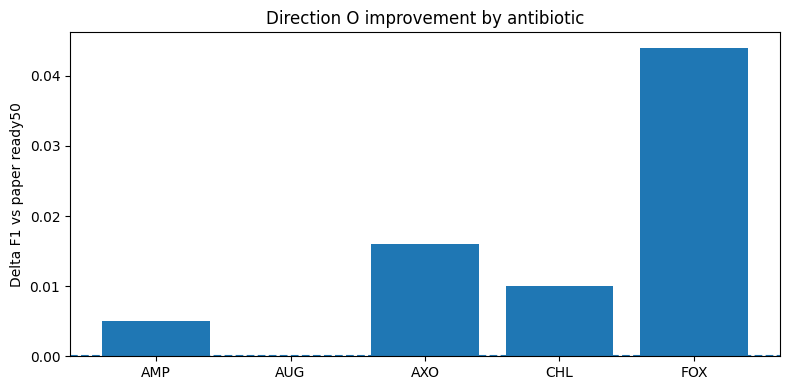

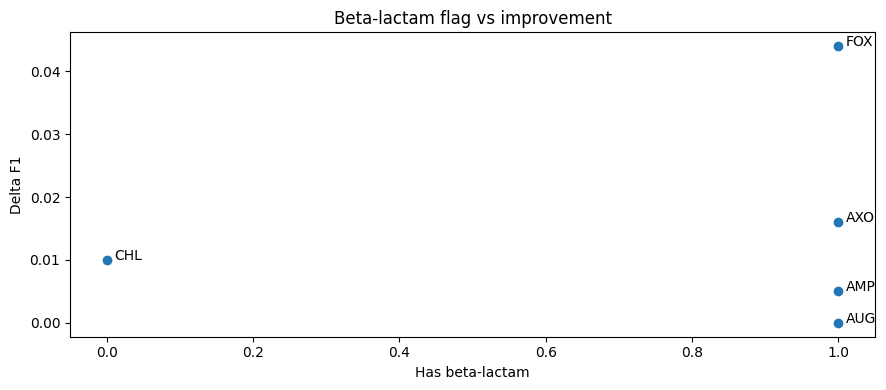

,broad_class,feature_module_type,count
0,beta_lactam,ensemble_selection,1
1,beta_lactam,marker_aware_hybrid,2
2,beta_lactam_combination,paper_marker_only,1
3,protein_synthesis_inhibitor,accessory_selected,1


In [ ]:

# =========================
# 7. Direction P plots
# =========================

plot_df = analysis_df.copy()

plt.figure(figsize=(8,4))
plt.bar(plot_df["drug"], plot_df["delta_f1"])
plt.axhline(0, linestyle="--")
plt.ylabel("Delta F1 vs paper ready50")
plt.title("Direction O improvement by antibiotic")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_O_delta_f1_by_antibiotic.png", dpi=200)
plt.show()

plt.figure(figsize=(9,4))
plt.scatter(plot_df["has_beta_lactam"], plot_df["delta_f1"])
for _, r in plot_df.iterrows():
    plt.text(r["has_beta_lactam"] + 0.01, r["delta_f1"], r["drug"])
plt.xlabel("Has beta-lactam")
plt.ylabel("Delta F1")
plt.title("Beta-lactam flag vs improvement")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beta_lactam_vs_delta_f1.png", dpi=200)
plt.show()

display(plot_df.groupby(["broad_class", "feature_module_type"]).size().reset_index(name="count"))


# Direction Q — optional genome–drug interaction model

Phần này cần clone repo và đọc ma trận gen phụ. Nếu bạn chỉ cần phân tích Direction P, có thể dừng ở đây.


In [ ]:

# =========================
# 8. Helper functions for Direction Q
# =========================

def run_cmd(cmd):
    print("RUN:", cmd)
    return os.system(cmd)

def list_files(root, suffixes=None):
    root = Path(root)
    files = []
    for p in root.rglob("*"):
        if p.is_file() and (suffixes is None or p.suffix.lower() in suffixes):
            files.append(p)
    return files

def find_largest_table(root):
    files = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if not files:
        raise FileNotFoundError(root)
    return sorted(files, key=lambda p: p.stat().st_size, reverse=True)[0]

def read_table_flexible(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() in [".tsv", ".txt"]:
        df = pd.read_csv(path, sep="\\t")
        if df.shape[1] == 1:
            df = pd.read_csv(path)
        return df
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(path)

def make_sample_index(n):
    return pd.Index([f"sample_{i}" for i in range(n)], name="sample_id")

def coerce_numeric_features(df):
    out = df.copy()
    drop_cols = []
    for c in out.columns:
        if out[c].dtype == "object":
            converted = pd.to_numeric(out[c], errors="coerce")
            if converted.notna().mean() > 0.95:
                out[c] = converted.fillna(0)
            else:
                drop_cols.append(c)
    if drop_cols:
        out = out.drop(columns=drop_cols)
    return out.fillna(0)

def parse_label_series(y_raw):
    y = y_raw.copy()
    if isinstance(y, pd.DataFrame):
        candidates = [c for c in y.columns if any(k in c.lower() for k in ["label", "phenotype", "result", "concl"])]
        col = candidates[0] if candidates else y.columns[-1]
        y = y[col]
    y = y.replace({"S":0, "I":0, "R":1, "s":0, "i":0, "r":1,
                   "Susceptible":0, "Intermediate":0, "Resistant":1})
    return pd.to_numeric(y, errors="coerce")

def find_drug_label_file(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    exact = drug_dir / f"{drug}_label.csv"
    if exact.exists():
        return exact
    candidates = list(drug_dir.glob("*label*.csv"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(drug)

def load_y_for_drug(drug):
    ydf = pd.read_csv(find_drug_label_file(drug))
    y = parse_label_series(ydf)
    y = y[y.notna()].reset_index(drop=True).astype(int)
    y.index = make_sample_index(len(y))
    return y

def score_binary(y_true, y_pred, y_prob):
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        balanced_accuracy=balanced_accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        f1=f1_score(y_true, y_pred, zero_division=0),
        auroc=roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        auprc=average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    )


In [ ]:

# =========================
# 9. Load Salmonella accessory data for Direction Q
# =========================

if not REPO_DIR.exists():
    run_cmd(f'git clone --depth 1 {REPO_URL} "{REPO_DIR}"')
else:
    print("Repo exists:", REPO_DIR)

run_cmd("apt-get update -qq")
run_cmd("apt-get install -y unrar > /dev/null")

accessory_extract_dir = EXTRACT_DIR / "accessory_gene"
accessory_extract_dir.mkdir(parents=True, exist_ok=True)

accessory_rar = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"

if not any(accessory_extract_dir.glob("*")):
    if accessory_rar.exists():
        run_cmd(f'unrar x -o+ "{accessory_rar}" "{accessory_extract_dir}/" > /dev/null')
    else:
        local_rar = BASE_DIR / "accessory_gene_existence_matrix.rar"
        url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
        run_cmd(f'wget -q -O "{local_rar}" "{url}"')
        run_cmd(f'unrar x -o+ "{local_rar}" "{accessory_extract_dir}/" > /dev/null')

accessory_path = find_largest_table(accessory_extract_dir)
X_accessory = coerce_numeric_features(read_table_flexible(accessory_path))
X_accessory.index = make_sample_index(X_accessory.shape[0])

print("X_accessory:", X_accessory.shape)
display(X_accessory.iloc[:3,:5])


RUN: git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git "/content/salmonella_direction_PQ_chemical/Antimicrobial-resistance-prediction-in-Salmonella"
RUN: apt-get update -qq
RUN: apt-get install -y unrar > /dev/null
RUN: unrar x -o+ "/content/salmonella_direction_PQ_chemical/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar" "/content/salmonella_direction_PQ_chemical/extracted/accessory_gene/" > /dev/null
X_accessory: (1167, 18125)


,ldtD,golT,GXP82_000609,D1K42_06100,astB
sample_id,,,,,
sample_0,1,1,1,1,1
sample_1,1,1,1,1,1
sample_2,1,1,1,1,1


In [ ]:

# =========================
# 10. Build sample-drug pair dataset
# =========================

# Select shared genome features using any-resistant label
ys = []
for drug in DRUGS:
    ys.append(load_y_for_drug(drug).rename(drug))
Y_wide = pd.concat(ys, axis=1)
any_resistant = (Y_wide.sum(axis=1) > 0).astype(int)

scores, _ = chi2(X_accessory.clip(lower=0), any_resistant)
s = pd.Series(scores, index=X_accessory.columns).replace([np.inf, -np.inf], np.nan).fillna(0)
selected_genome_features_Q = list(s.sort_values(ascending=False).head(MAX_GENOME_FEATURES_Q).index)

X_genome_base = X_accessory[selected_genome_features_Q].copy()
print("Selected genome features:", X_genome_base.shape)

# Chemical numeric features
chem_feature_cols = []
for c in chem_drug_df.columns:
    if c in ["has_beta_lactam", "has_beta_lactamase_inhibitor", "combination_drug", "n_components"]:
        chem_feature_cols.append(c)
    elif any(c.endswith(suf) for suf in ["_mean", "_sum", "_max"]):
        if pd.api.types.is_numeric_dtype(chem_drug_df[c]):
            chem_feature_cols.append(c)

chem_numeric_df = chem_drug_df[["drug"] + chem_feature_cols].copy()
chem_numeric_df[chem_feature_cols] = chem_numeric_df[chem_feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

pair_rows = []
for drug in DRUGS:
    y = load_y_for_drug(drug)
    chem_row = chem_numeric_df[chem_numeric_df["drug"] == drug].iloc[0]
    for sample_id in y.index:
        row = {"sample_id": sample_id, "drug": drug, "y": int(y.loc[sample_id])}
        for c in chem_feature_cols:
            row[f"drug_{c}"] = chem_row[c]
        pair_rows.append(row)

pair_meta = pd.DataFrame(pair_rows)
display(pair_meta.head())
print("Pair rows:", pair_meta.shape, "positive rate:", pair_meta["y"].mean())
pair_meta.to_csv(OUTPUT_DIR / "sample_drug_pair_metadata.csv", index=False)


Selected genome features: (1167, 500)


,sample_id,drug,y,drug_has_beta_lactam,drug_has_beta_lactamase_inhibitor,drug_combination_drug,drug_n_components,drug_MolecularWeight_mean,drug_MolecularWeight_sum,drug_MolecularWeight_max,...,drug_RotatableBondCount_max,drug_HeavyAtomCount_mean,drug_HeavyAtomCount_sum,drug_HeavyAtomCount_max,drug_Complexity_mean,drug_Complexity_sum,drug_Complexity_max,drug_Charge_mean,drug_Charge_sum,drug_Charge_max
0,sample_0,AMP,0,1,0,0,1,349.4,349.4,349.4,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0
1,sample_1,AMP,0,1,0,0,1,349.4,349.4,349.4,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0
2,sample_2,AMP,0,1,0,0,1,349.4,349.4,349.4,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0
3,sample_3,AMP,1,1,0,0,1,349.4,349.4,349.4,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0
4,sample_4,AMP,1,1,0,0,1,349.4,349.4,349.4,...,4.0,24.0,24.0,24.0,562.0,562.0,562.0,0.0,0.0,0.0


Pair rows: (5835, 34) positive rate: 0.1038560411311054


In [ ]:

# =========================
# 11. Evaluate Direction Q
# =========================

def build_pair_matrix(pair_meta, include_genome=True, include_chem=True, include_drug_onehot=True):
    parts = []
    if include_genome:
        Xg = X_genome_base.loc[pair_meta["sample_id"].values].reset_index(drop=True)
        Xg.columns = [f"g_{i}" for i in range(Xg.shape[1])]
        parts.append(Xg)
    if include_chem:
        chem_cols = [c for c in pair_meta.columns if c.startswith("drug_") and c != "drug"]
        parts.append(pair_meta[chem_cols].reset_index(drop=True))
    if include_drug_onehot:
        parts.append(pd.get_dummies(pair_meta["drug"], prefix="drug_id").reset_index(drop=True))
    X = pd.concat(parts, axis=1).apply(pd.to_numeric, errors="coerce").fillna(0)
    y = pair_meta["y"].astype(int).values
    return X, y

settings_Q = {
    "genome_only": dict(include_genome=True, include_chem=False, include_drug_onehot=False),
    "drug_chemical_only": dict(include_genome=False, include_chem=True, include_drug_onehot=True),
    "genome_plus_drug_id": dict(include_genome=True, include_chem=False, include_drug_onehot=True),
    "genome_plus_chemical": dict(include_genome=True, include_chem=True, include_drug_onehot=True),
}

model_names = ["LR_balanced", "RF_balanced"] + (["XGB_weighted"] if HAS_XGB else [])

def make_model(model_name, y_train, seed):
    if model_name == "LR_balanced":
        return LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs", random_state=seed)
    if model_name == "RF_balanced":
        return RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight="balanced_subsample", random_state=seed, n_jobs=-1)
    if model_name == "XGB_weighted":
        pos = max(int(np.sum(y_train)), 1)
        neg = max(int(len(y_train) - np.sum(y_train)), 1)
        return xgb.XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.04, subsample=0.85, colsample_bytree=0.85,
                                 eval_metric="logloss", scale_pos_weight=neg/pos, random_state=seed, n_jobs=-1)
    raise ValueError(model_name)

rows = []
unique_samples = sorted(pair_meta["sample_id"].unique())

for seed in RANDOM_SEEDS:
    train_samples, test_samples = train_test_split(unique_samples, test_size=0.2, random_state=seed)
    train_samples, val_samples = train_test_split(train_samples, test_size=0.25, random_state=seed+1000)

    train_mask = pair_meta["sample_id"].isin(train_samples).values
    val_mask = pair_meta["sample_id"].isin(val_samples).values
    test_mask = pair_meta["sample_id"].isin(test_samples).values

    for setting_name, kwargs in settings_Q.items():
        X_all, y_all = build_pair_matrix(pair_meta, **kwargs)
        X_train = X_all.loc[train_mask].reset_index(drop=True)
        y_train = y_all[train_mask]
        X_val = X_all.loc[val_mask].reset_index(drop=True)
        y_val = y_all[val_mask]
        X_test = X_all.loc[test_mask].reset_index(drop=True)
        y_test = y_all[test_mask]

        cols = [f"f_{i}" for i in range(X_train.shape[1])]
        X_train.columns = cols; X_val.columns = cols; X_test.columns = cols

        for model_name in model_names:
            model = make_model(model_name, y_train, seed)
            model.fit(X_train, y_train)
            pv = model.predict_proba(X_val)[:,1]
            pt = model.predict_proba(X_test)[:,1]

            thresholds = np.linspace(0.05, 0.95, 91)
            best_t, best_score = 0.5, -1
            for t in thresholds:
                predv = (pv >= t).astype(int)
                sc = f1_score(y_val, predv, zero_division=0)
                if sc > best_score:
                    best_score = sc
                    best_t = t

            pred = (pt >= best_t).astype(int)
            rows.append({"seed": seed, "setting": setting_name, "model": model_name, "threshold": best_t, **score_binary(y_test, pred, pt)})

q_results = pd.DataFrame(rows)
q_results.to_csv(OUTPUT_DIR / "direction_Q_multidrug_results.csv", index=False)

q_summary = q_results.groupby(["setting", "model"])[["balanced_accuracy","precision","recall","f1","auroc","auprc"]].agg(["mean","std"]).reset_index()
q_summary.columns = ["_".join([str(x) for x in col if str(x) != ""]) if isinstance(col, tuple) else col for col in q_summary.columns]
q_summary = q_summary.sort_values(["f1_mean","balanced_accuracy_mean","auprc_mean"], ascending=False)
display(q_summary)
q_summary.to_csv(OUTPUT_DIR / "direction_Q_multidrug_summary.csv", index=False)


,setting,model,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
8,genome_plus_chemical,XGB_weighted,0.954886,0.028656,0.941266,0.030633,0.916107,0.055929,0.928185,0.040609,0.975032,0.022039,0.929627,0.055040
11,genome_plus_drug_id,XGB_weighted,0.953500,0.031033,0.944123,0.027940,0.913021,0.061250,0.927812,0.041210,0.974296,0.021145,0.928262,0.055147
7,genome_plus_chemical,RF_balanced,0.948550,0.029154,0.860342,0.075722,0.913879,0.055543,0.885409,0.056831,0.970739,0.029885,0.914899,0.063611
9,genome_plus_drug_id,LR_balanced,0.924105,0.025109,0.804293,0.047852,0.872320,0.050566,0.836391,0.041524,0.964718,0.022383,0.854752,0.060393
6,genome_plus_chemical,LR_balanced,0.920654,0.022291,0.809291,0.053222,0.864459,0.044734,0.835350,0.040560,0.964958,0.022844,0.855616,0.062782
10,genome_plus_drug_id,RF_balanced,0.900122,0.062021,0.837945,0.077926,0.817995,0.123114,0.825614,0.091125,0.965643,0.031920,0.882252,0.065716
5,genome_only,XGB_weighted,0.907013,0.021542,0.688571,0.046795,0.858472,0.045828,0.763574,0.039131,0.954332,0.017566,0.811985,0.059693
3,genome_only,LR_balanced,0.901887,0.046269,0.625710,0.037907,0.863199,0.101514,0.723907,0.051547,0.948530,0.016372,0.783669,0.054486
4,genome_only,RF_balanced,0.889328,0.055148,0.618210,0.076032,0.837696,0.110447,0.710271,0.083910,0.944980,0.037987,0.780151,0.080452
0,drug_chemical_only,LR_balanced,0.587187,0.016424,0.139126,0.021899,0.623122,0.105090,0.225237,0.024505,0.615225,0.020972,0.139726,0.014213


In [ ]:

# =========================
# 12. Auto conclusion + zip
# =========================

best_q = q_summary.iloc[0]

lines = []
lines.append("# Direction P/Q — Auto conclusion")
lines.append("")
lines.append("## Direction P")
for _, row in analysis_df.iterrows():
    lines.append(
        f"- {row['drug']} ({row['drug_class']}): best module = {row['setting_best']}; "
        f"module type = {row['feature_module_type']}; delta F1 = {row['delta_f1']:+.3f}."
    )

lines.append("")
lines.append("## Rule cho thuốc mới")
for _, row in rules_df.iterrows():
    lines.append(f"- Nếu {row['condition']} → bắt đầu với {row['recommended_starting_modules']}.")

lines.append("")
lines.append("## Direction Q")
lines.append(
    f"Best multi-drug setting = {best_q['setting']} + {best_q['model']}; "
    f"F1={best_q['f1_mean']:.3f}; balanced accuracy={best_q['balanced_accuracy_mean']:.3f}; AUPRC={best_q['auprc_mean']:.3f}."
)

lines.append("")
lines.append("## Diễn giải")
lines.append("- Với chỉ 5 thuốc, chemical descriptors nên dùng chủ yếu để giải thích Direction O và tạo rule chọn feature cho thuốc mới.")
lines.append("- Direction Q là thử nghiệm phụ; muốn chemical features thật sự mạnh thì cần mở rộng thêm nhiều thuốc hơn.")

conclusion = "\\n".join(lines)
print(conclusion)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_PQ.md", "w", encoding="utf-8") as f:
    f.write(conclusion)

zip_path = BASE_DIR / "salmonella_direction_PQ_outputs.zip"
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace(".zip",""), "zip", OUTPUT_DIR)
print("Output:", OUTPUT_DIR)
print("Zip:", zip_path)


# Direction P/Q — Auto conclusion\n\n## Direction P\n- AMP (penicillin): best module = paper_ready50_plus_chi2_200; module type = marker_aware_hybrid; delta F1 = +0.005.\n- AUG (penicillin + beta-lactamase inhibitor): best module = paper_ready50; module type = paper_marker_only; delta F1 = +0.000.\n- AXO (third-generation cephalosporin): best module = paper_ready50_plus_chi2_500; module type = marker_aware_hybrid; delta F1 = +0.016.\n- CHL (chloramphenicol class): best module = accessory_chi2_500; module type = accessory_selected; delta F1 = +0.010.\n- FOX (cephamycin): best module = ensemble_top_500; module type = ensemble_selection; delta F1 = +0.044.\n\n## Rule cho thuốc mới\n- Nếu beta-lactam with clear resistance markers → bắt đầu với paper/known markers + accessory 200/500.\n- Nếu cephalosporin/cephamycin or plasmid/AmpC-related beta-lactam → bắt đầu với marker-aware hybrid or ensemble top 500.\n- Nếu non-beta-lactam, efflux/transporter/mobile-element-related resistance → bắt đầu